# Used Car Price Prediction

## 1) Problem statement.

* This dataset comprises used cars sold on cardehko.com in India as well as important features of these cars.
* If user can predict the price of the car based on input features.
* Prediction results can be used to give new seller the price suggestion based on market condition.

## 2) Data Collection.
* The Dataset is collected from scrapping from cardheko webiste
* The data consists of 13 column and 15411 rows.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv('cardekho_imputated.csv')

In [3]:
df.drop(columns=['Unnamed: 0'],axis=1,inplace=True)

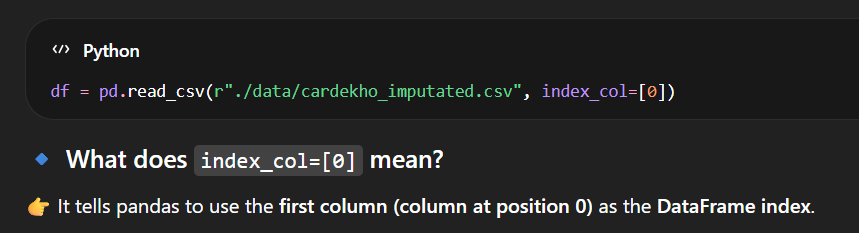

So; that column will be used as data-frame INDEX and will NOT be considered as the Column in Data-Frame.

In [4]:
df.head()

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


## Data Cleaning
### Handling Missing values

* Handling Missing values 
* Handling Duplicates
* Check data type
* Understand the dataset

In [5]:
# Check Null values-:
df.isnull().sum()

car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

In [6]:
## Remove Unnecessary Columns
df.drop('car_name', axis=1, inplace=True)
df.drop('brand', axis=1, inplace=True)

In [7]:
df.head()

,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [8]:
df['model'].unique()

array(['Alto', 'Grand', 'i20', 'Ecosport', 'Wagon R', 'i10', 'Venue',
       'Swift', 'Verna', 'Duster', 'Cooper', 'Ciaz', 'C-Class', 'Innova',
       'Baleno', 'Swift Dzire', 'Vento', 'Creta', 'City', 'Bolero',
       'Fortuner', 'KWID', 'Amaze', 'Santro', 'XUV500', 'KUV100', 'Ignis',
       'RediGO', 'Scorpio', 'Marazzo', 'Aspire', 'Figo', 'Vitara',
       'Tiago', 'Polo', 'Seltos', 'Celerio', 'GO', '5', 'CR-V',
       'Endeavour', 'KUV', 'Jazz', '3', 'A4', 'Tigor', 'Ertiga', 'Safari',
       'Thar', 'Hexa', 'Rover', 'Eeco', 'A6', 'E-Class', 'Q7', 'Z4', '6',
       'XF', 'X5', 'Hector', 'Civic', 'D-Max', 'Cayenne', 'X1', 'Rapid',
       'Freestyle', 'Superb', 'Nexon', 'XUV300', 'Dzire VXI', 'S90',
       'WR-V', 'XL6', 'Triber', 'ES', 'Wrangler', 'Camry', 'Elantra',
       'Yaris', 'GL-Class', '7', 'S-Presso', 'Dzire LXI', 'Aura', 'XC',
       'Ghibli', 'Continental', 'CR', 'Kicks', 'S-Class', 'Tucson',
       'Harrier', 'X3', 'Octavia', 'Compass', 'CLS', 'redi-GO', 'Glanza',
       

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   model              15411 non-null  object 
 1   vehicle_age        15411 non-null  int64  
 2   km_driven          15411 non-null  int64  
 3   seller_type        15411 non-null  object 
 4   fuel_type          15411 non-null  object 
 5   transmission_type  15411 non-null  object 
 6   mileage            15411 non-null  float64
 7   engine             15411 non-null  int64  
 8   max_power          15411 non-null  float64
 9   seats              15411 non-null  int64  
 10  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(5), object(4)
memory usage: 1.3+ MB


In [10]:
df['transmission_type'].dtype

dtype('O')

In [11]:
df['max_power'].dtype

dtype('float64')

In [12]:
df['seats'].dtype

dtype('int64')

In [13]:
# Getting all Different types of Features-:
num_features = [feature for feature in df.columns if df[feature].dtype != 'O']
print(f"Num of Numerical Features: {len(num_features)}")
cat_features = [feature for feature in df.columns if df[feature].dtype == 'O']
print(f"Num of Categorical Features: {len(cat_features)}")
discrete_features = [feature for feature in num_features if len(df[feature].unique()) <=25]
print(f"Num of Discrete Features: {len(discrete_features)}")
continuous_features = [feature for feature in num_features if  feature not in discrete_features]
print(f"Num of Continuous Features: {len(continuous_features)}")

Num of Numerical Features: 7
Num of Categorical Features: 4
Num of Discrete Features: 2
Num of Continuous Features: 5


In [14]:
# Independent feature and dependent feature-:
from sklearn.model_selection import train_test_split
X = df.drop(columns=['selling_price'],axis=1)
y = df['selling_price']

In [15]:
X

,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats
0,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5
1,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5
2,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5
3,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5
4,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5
...,...,...,...,...,...,...,...,...,...,...
15406,i10,9,10723,Dealer,Petrol,Manual,19.81,1086,68.05,5
15407,Ertiga,2,18000,Dealer,Petrol,Manual,17.50,1373,91.10,7
15408,Rapid,6,67000,Dealer,Diesel,Manual,21.14,1498,103.52,5
15409,XUV500,5,3800000,Dealer,Diesel,Manual,16.00,2179,140.00,7


In [16]:
y

0         120000
1         550000
2         215000
3         226000
4         570000
          ...   
15406     250000
15407     925000
15408     425000
15409    1225000
15410    1200000
Name: selling_price, Length: 15411, dtype: int64

In [17]:
X.head()

,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats
0,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5
1,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5
2,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5
3,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5
4,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5


## Feature Encoding and Scaling
**One Hot Encoding for Columns which had lesser unique values and not ordinal**
* One hot encoding is a process by which categorical variables are converted into a form that could be provided to ML algorithms to do a better job in prediction.

In [18]:
len(df['model'].unique())

120

In [19]:
df['model'].value_counts()

model
i20             906
Swift Dzire     890
Swift           781
Alto            778
City            757
               ... 
Altroz            1
C                 1
Ghost             1
Quattroporte      1
Gurkha            1
Name: count, Length: 120, dtype: int64

In [20]:
df['model'] = df['model'].str.lower()

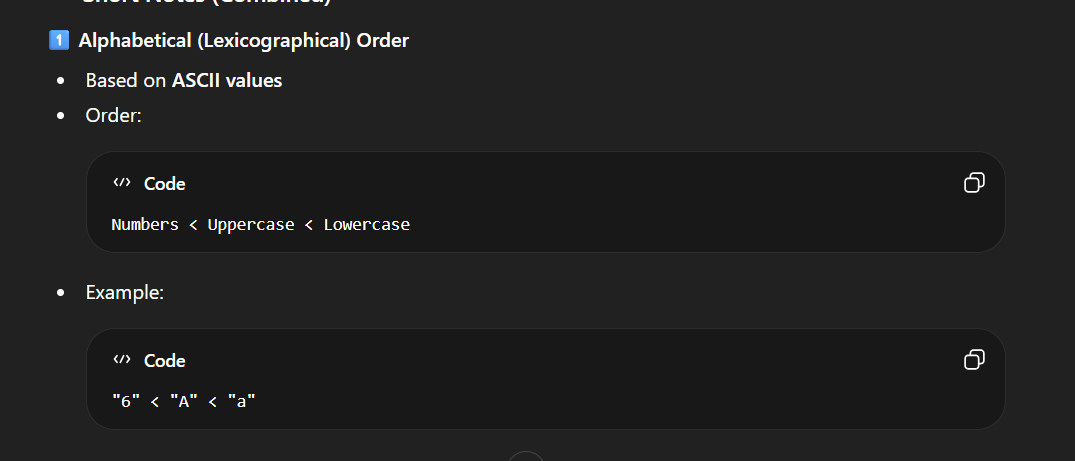
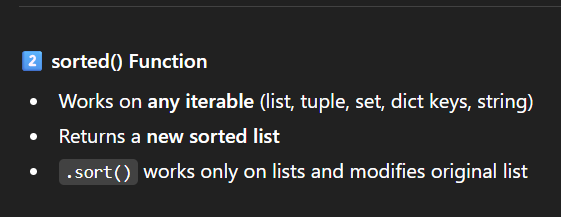

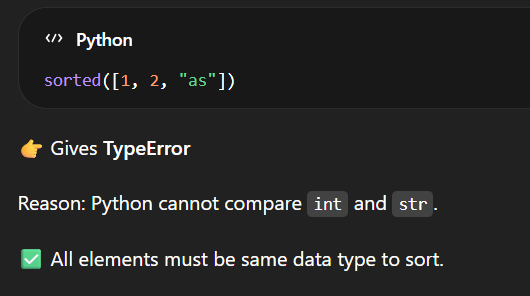

In [21]:
sorted(df['model'].unique())

['3',
 '5',
 '6',
 '7',
 'a4',
 'a6',
 'a8',
 'alto',
 'altroz',
 'alturas',
 'amaze',
 'aspire',
 'aura',
 'baleno',
 'bolero',
 'c',
 'c-class',
 'camry',
 'carnival',
 'cayenne',
 'celerio',
 'ciaz',
 'city',
 'civic',
 'cls',
 'compass',
 'continental',
 'cooper',
 'cr',
 'cr-v',
 'creta',
 'd-max',
 'duster',
 'dzire lxi',
 'dzire vxi',
 'dzire zxi',
 'e-class',
 'ecosport',
 'eeco',
 'elantra',
 'endeavour',
 'ertiga',
 'es',
 'f-pace',
 'figo',
 'fortuner',
 'freestyle',
 'ghibli',
 'ghost',
 'gl-class',
 'glanza',
 'gls',
 'go',
 'grand',
 'gtc4lusso',
 'gurkha',
 'harrier',
 'hector',
 'hexa',
 'i10',
 'i20',
 'ignis',
 'innova',
 'jazz',
 'kicks',
 'kuv',
 'kuv100',
 'kwid',
 'macan',
 'marazzo',
 'mux',
 'nexon',
 'nx',
 'octavia',
 'panamera',
 'polo',
 'q7',
 'quattroporte',
 'rapid',
 'redi-go',
 'redigo',
 'rover',
 'rx',
 's-class',
 's-presso',
 's90',
 'safari',
 'santro',
 'scorpio',
 'seltos',
 'superb',
 'swift',
 'swift dzire',
 'thar',
 'tiago',
 'tigor',
 'tribe

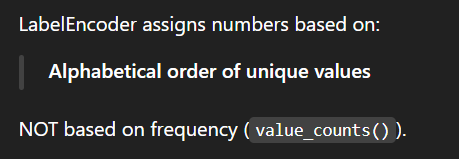

In [22]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
X['model'] = le.fit_transform(X["model"])

In [23]:
X['model']

0          7
1         54
2        118
3          7
4         38
        ... 
15406    117
15407     42
15408     77
15409    114
15410     25
Name: model, Length: 15411, dtype: int64

In [24]:
X['model'].unique()

array([  7,  54, 118,  38, 100, 117,  96,  88,  97,  32,  29,  24,  16,
        60,  13,  89,  95,  30,  25,  14,  45,  64,  10,  84, 114,  63,
        59,  78,  85,  68,  11,  44,  98,  91,  73,  86,  23,  49,   1,
        19,  41,  62,  61,   0,   4,  92,  42,  83,  90,  58,  79,  39,
         5,  36,  74, 116,   2, 111, 106,  57,  26,  31,  22, 103,  77,
        46,  87,  70, 113,  34,  82,  99, 112,  93,  37, 101,  20,  40,
       115,  47,   3,  81,  33,  12, 107,  51,  28,  18,  65,  80,  94,
        56, 104,  71,  27,  17, 119,  53,  67, 105,  35, 109,  43,   6,
        66,  50,  48, 102, 110, 108,  72,   9,   8,  69,  21,  15,  76,
        52,  75,  55])

In [25]:
X.head()

,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats
0,7,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5
1,54,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5
2,118,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5
3,7,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5
4,38,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5


In [26]:
X['seller_type'].unique(), X['fuel_type'].unique(),X['transmission_type'].unique()

(array(['Individual', 'Dealer', 'Trustmark Dealer'], dtype=object),
 array(['Petrol', 'Diesel', 'CNG', 'LPG', 'Electric'], dtype=object),
 array(['Manual', 'Automatic'], dtype=object))

For these 3 columns-: seller_type; fuel_type and transmission_type 
we will apply O.H.E as number of categories/unique-values are VERY LESS

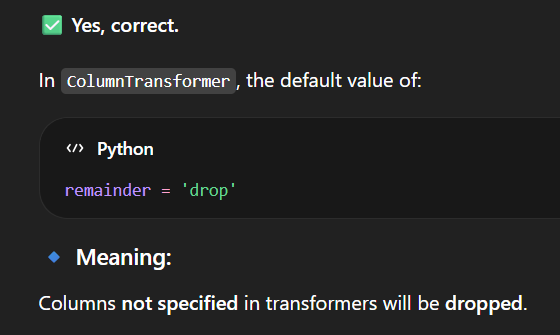

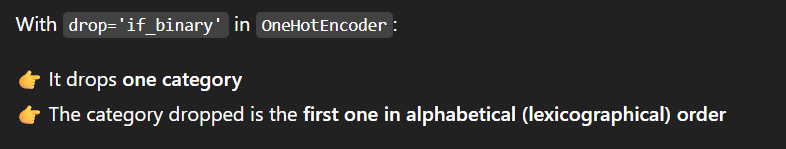

In [27]:
# Create Column transformer with 3 types of transformers-:
num_features = X.select_dtypes(exclude='object').columns
onehot_columns = ['seller_type','fuel_type','transmission_type']

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder(drop='first')


preprocessor  = ColumnTransformer(
    [
            ("OneHotEncoder",oh_transformer,onehot_columns),
            ("Standardization",numeric_transformer,num_features)
    ]
    ,remainder='passthrough')

In [28]:
X = preprocessor.fit_transform(X)

In [29]:
X

array([[ 1.        ,  0.        ,  0.        , ..., -1.32425883,
        -1.26335238, -0.40302241],
       [ 1.        ,  0.        ,  0.        , ..., -0.55471774,
        -0.43257082, -0.40302241],
       [ 1.        ,  0.        ,  0.        , ..., -0.55471774,
        -0.47911321, -0.40302241],
       ...,
       [ 0.        ,  0.        ,  1.        , ...,  0.02291783,
         0.06822523, -0.40302241],
       [ 0.        ,  0.        ,  1.        , ...,  1.32979434,
         0.91715831,  2.07344426],
       [ 0.        ,  0.        ,  0.        , ...,  0.02099878,
         0.39588361, -0.40302241]])

In [30]:
pd.DataFrame(X)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,-1.519714,0.983562,1.247335,-0.000276,-1.324259,-1.263352,-0.403022
1,1.0,0.0,0.0,0.0,0.0,1.0,1.0,-0.225693,-0.343933,-0.690016,-0.192071,-0.554718,-0.432571,-0.403022
2,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.536377,1.647309,0.084924,-0.647583,-0.554718,-0.479113,-0.403022
3,1.0,0.0,0.0,0.0,0.0,1.0,1.0,-1.519714,0.983562,-0.360667,0.292211,-0.936610,-0.779312,-0.403022
4,0.0,0.0,1.0,0.0,0.0,0.0,1.0,-0.666211,-0.012060,-0.496281,0.735736,0.022918,-0.046502,-0.403022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15406,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.508844,0.983562,-0.869744,0.026096,-0.767733,-0.757204,-0.403022
15407,0.0,0.0,0.0,0.0,0.0,1.0,1.0,-0.556082,-1.339555,-0.728763,-0.527711,-0.216964,-0.220803,2.073444
15408,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.407551,-0.012060,0.220539,0.344954,0.022918,0.068225,-0.403022
15409,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.426247,-0.343933,72.541850,-0.887326,1.329794,0.917158,2.073444


In [31]:
# separate dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape, X_test.shape

((12328, 14), (3083, 14))

# Model Training And Model Selection

In [32]:
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [33]:
def evaluate_model(true,pred):
    mse = mean_squared_error(true,pred)
    mae = mean_absolute_error(true,pred)
    rmse = np.sqrt(mse)
    Rsquare = r2_score(true,pred)
    return mae,rmse,Rsquare

In [34]:
# Model Tranining-:
models = {
    "Linear Regression":LinearRegression(),
    "Lasso":Lasso(),
    "Ridge":Ridge(),
    "KNeighbors Regressor":KNeighborsRegressor(),
    "Decision Tree":DecisionTreeRegressor(),
    "RandomForest Regressor":RandomForestRegressor(),
    "Adaboost Regresoor": AdaBoostRegressor(),
    "Gradient Boosting Regressor": GradientBoostingRegressor()
}

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train,y_train) # Train the Model

    # Make predicitons-:
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Evaluate Train and Test dataset-:
    model_train_mae, model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)

    model_test_mae, model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    print(list(models.keys())[i])

    
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    
    print('='*35)
    print('\n')

Linear Regression
Model performance for Training set
- Root Mean Squared Error: 553855.6665
- Mean Absolute Error: 268101.6071
- R2 Score: 0.6218
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 502543.5930
- Mean Absolute Error: 279618.5794
- R2 Score: 0.6645


Lasso
Model performance for Training set
- Root Mean Squared Error: 553855.6710
- Mean Absolute Error: 268099.2226
- R2 Score: 0.6218
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 502542.6696
- Mean Absolute Error: 279614.7461
- R2 Score: 0.6645


Ridge
Model performance for Training set
- Root Mean Squared Error: 553856.3160
- Mean Absolute Error: 268059.8015
- R2 Score: 0.6218
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 502533.8230
- Mean Absolute Error: 279557.2169
- R2 Score: 0.6645


KNeighbors Regressor
Model performance for Training set
- Root Mean Squared Error: 325873.0088
- Mean A

Since; in terms of r2_score -: Random Forest Regressor and KNN regressor and Gradient Boosting regressor algo are working very well.

So; we will select all 3 of them and do HYPER-PARAMETER TUNING to get the most optimal PARAMETERS and RESULTS from all 3 of these algorithms.

# Widely used parameters of Gradient Boosting Regressor is as follows [for HYPER-PARAMETER TUNING]-:

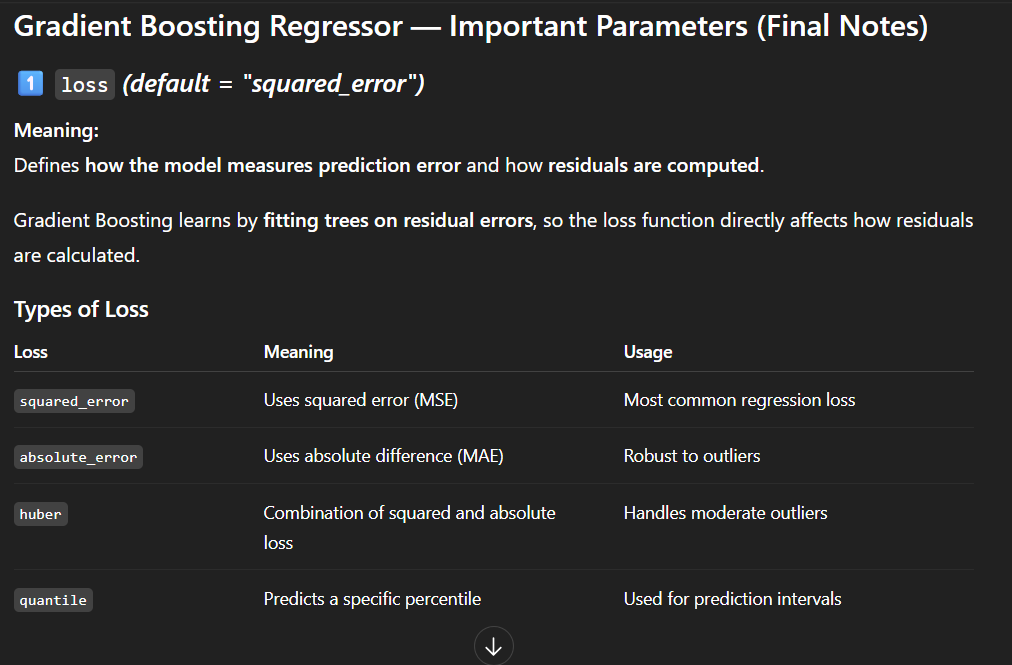
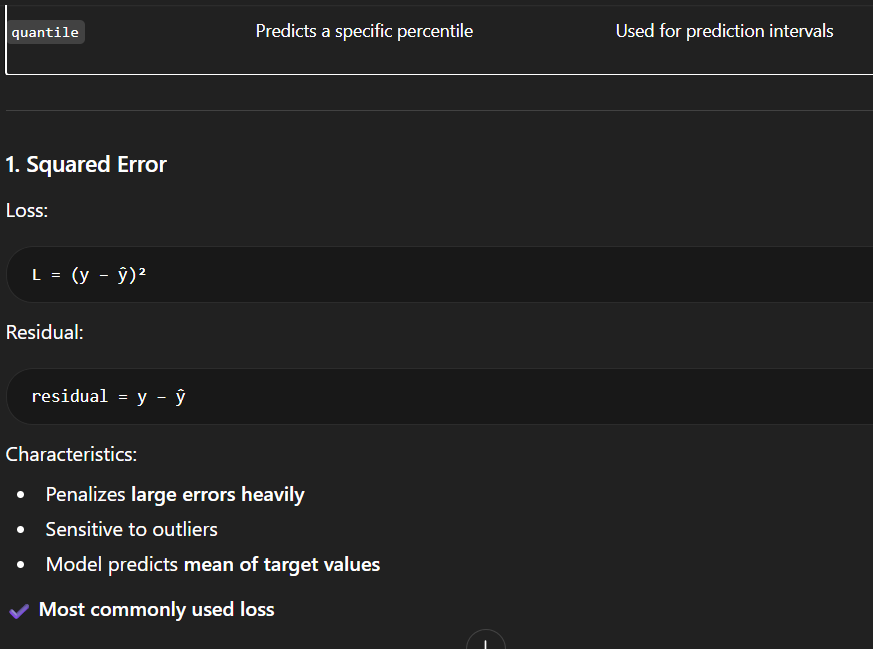
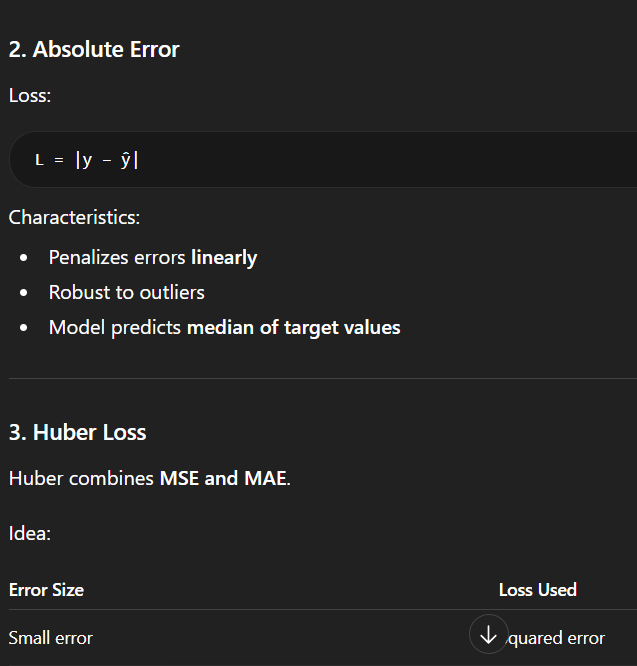
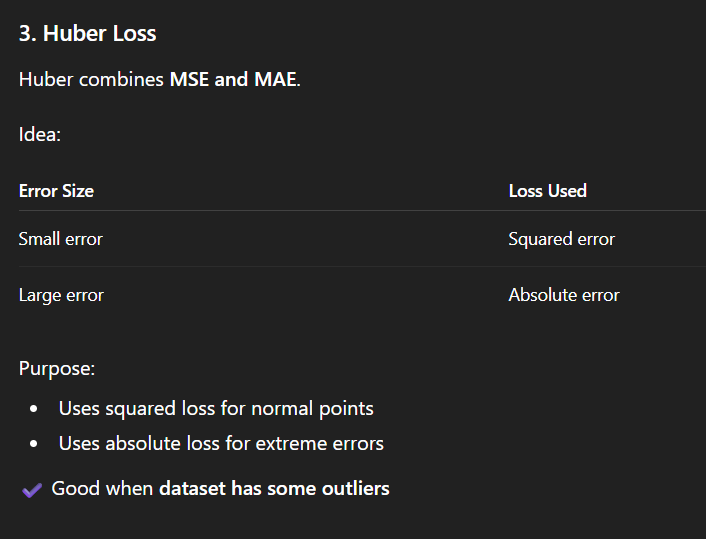
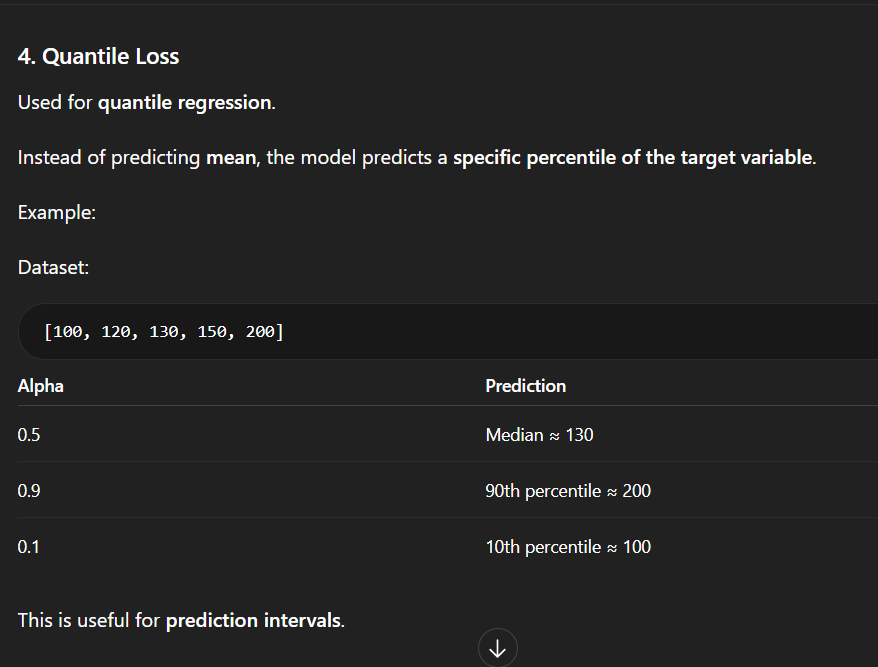
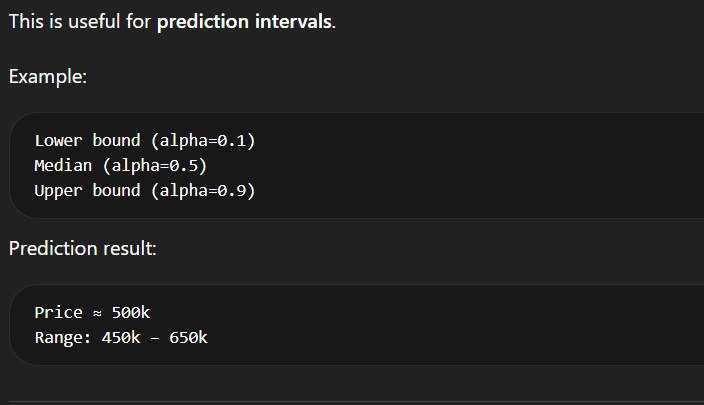
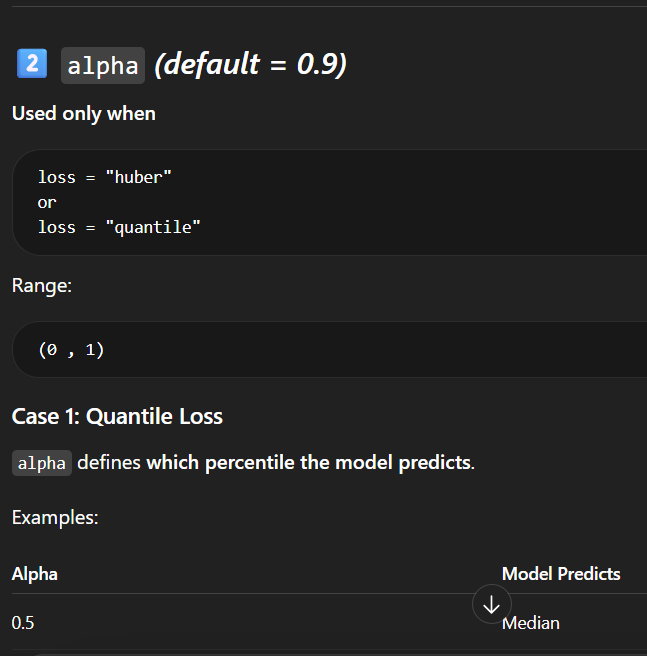
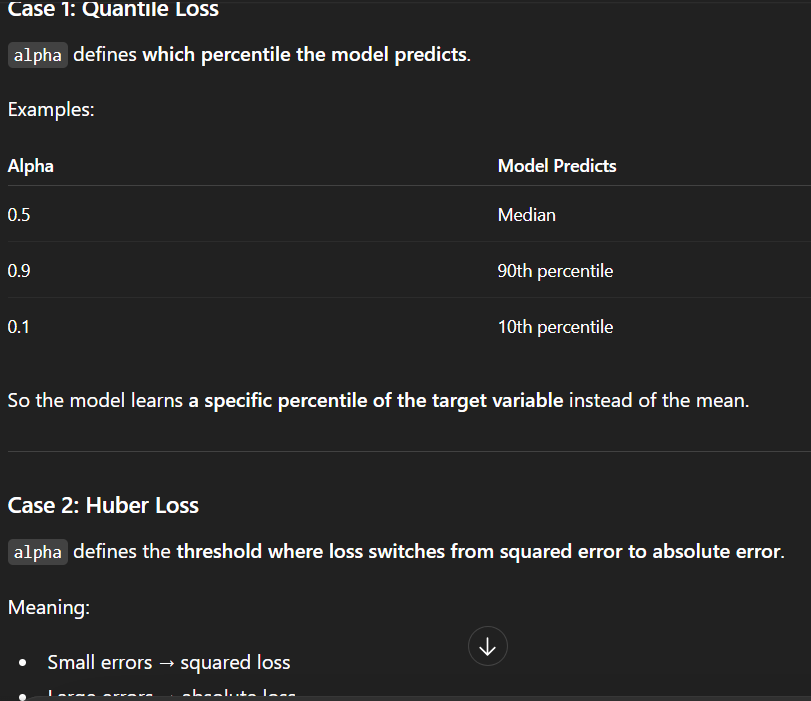
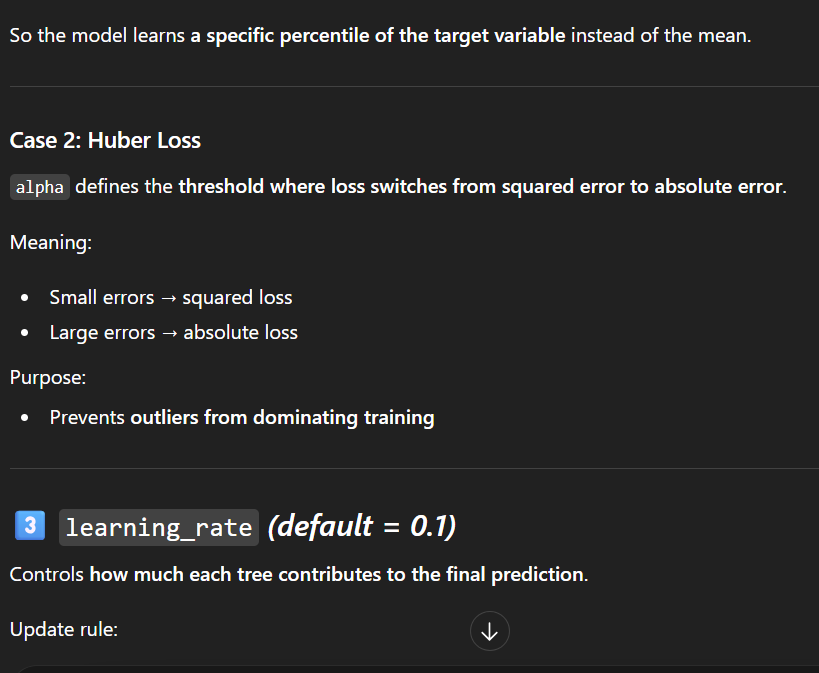

# In "loss" and "alpha" parameters documentation -: the "model" term  refers to the "BASE-MODEL / BASE-LEARNER"

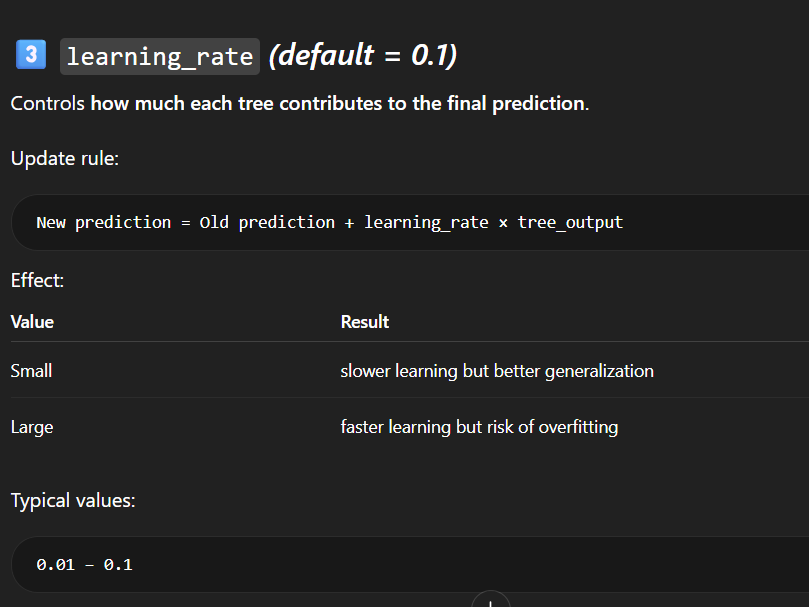
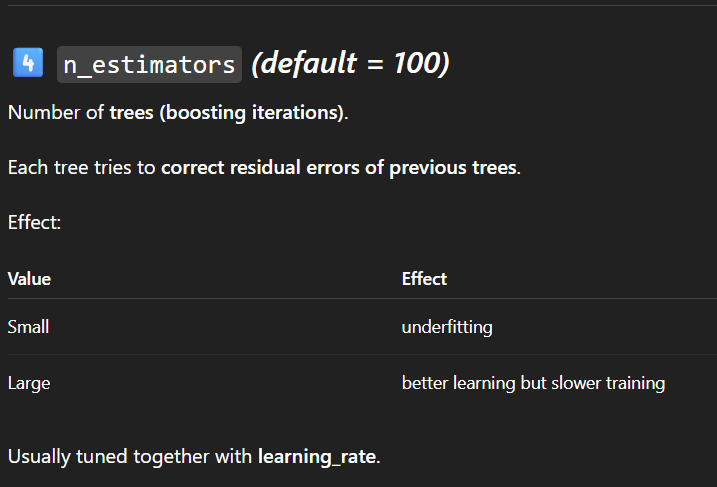
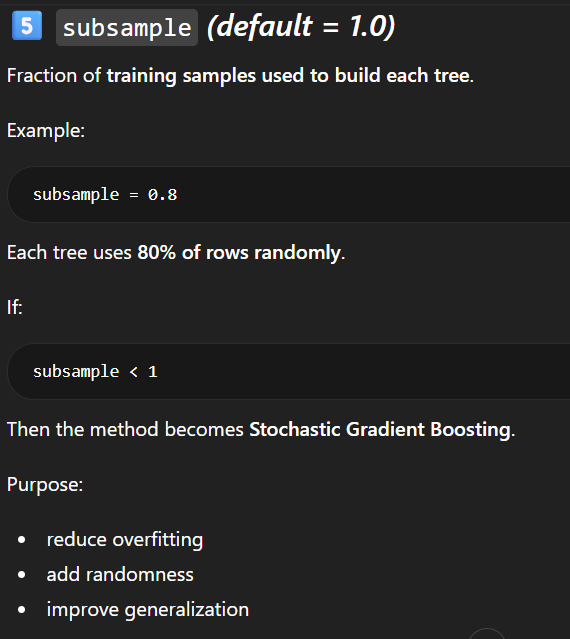
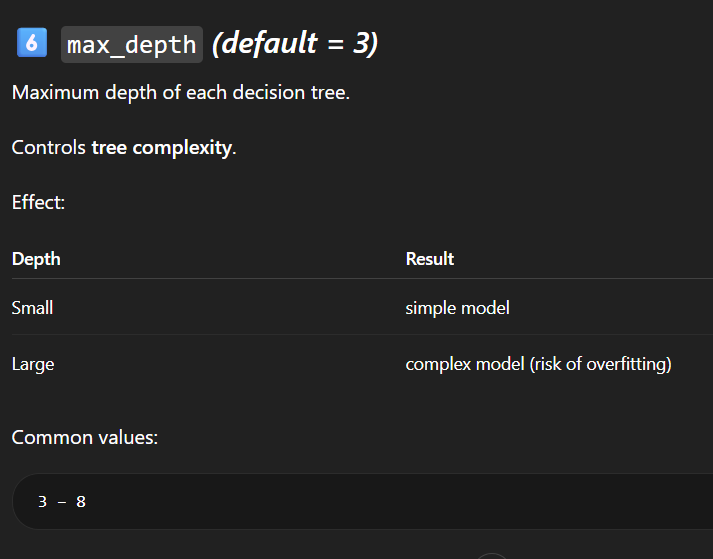
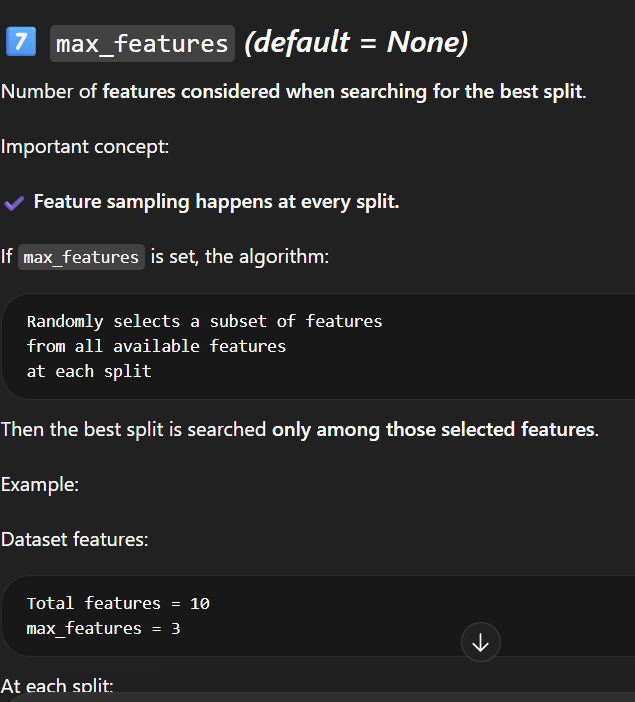
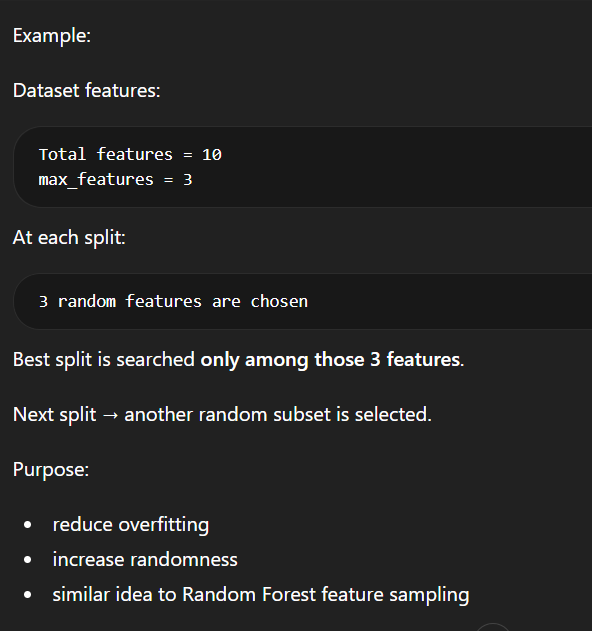
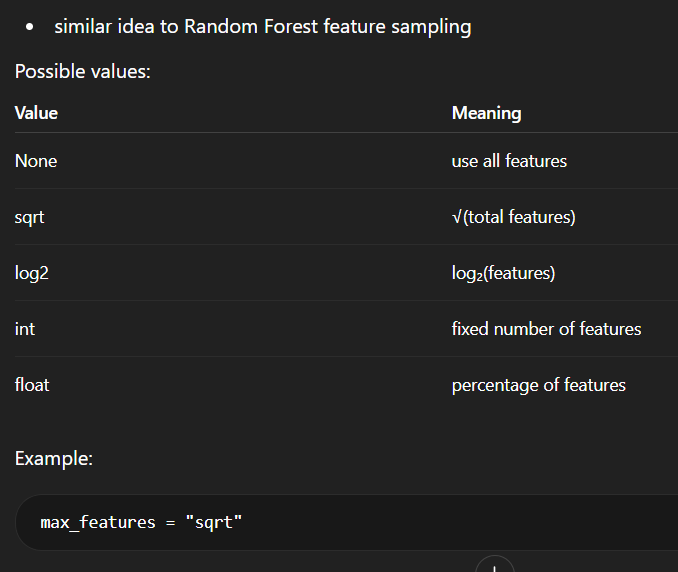
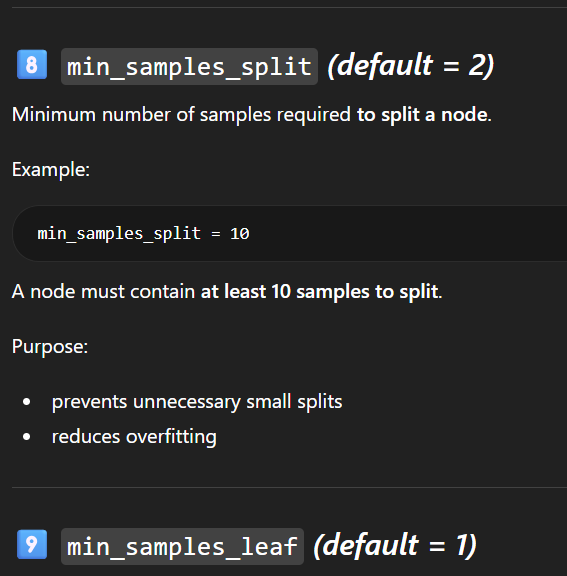
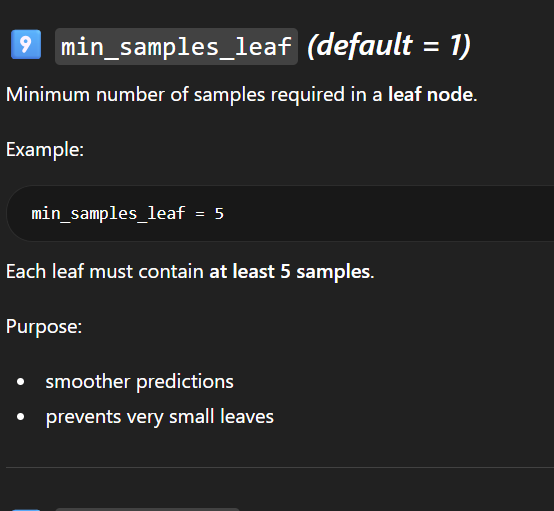
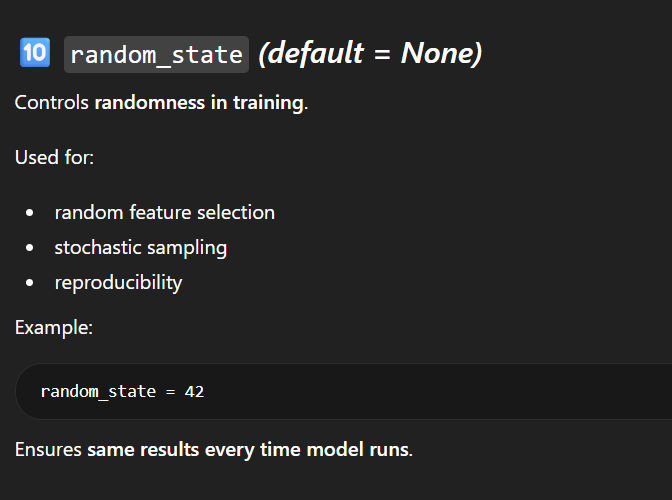
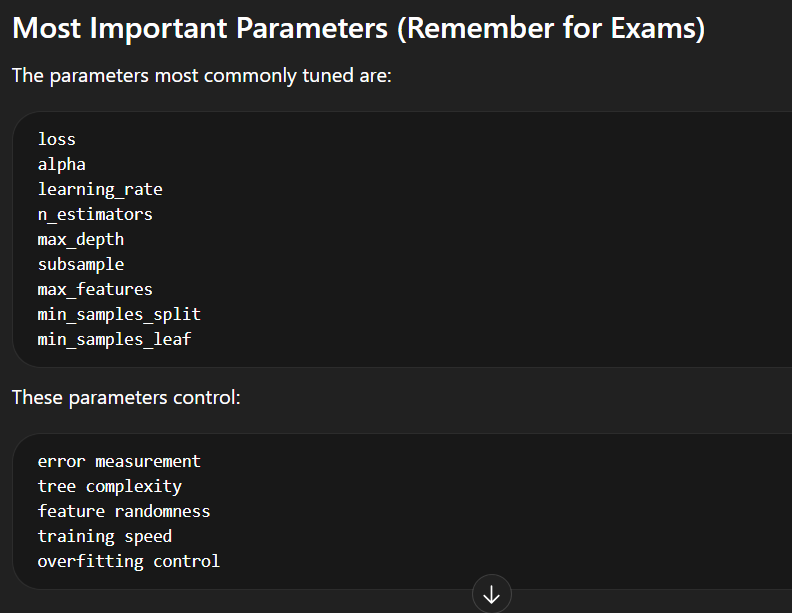

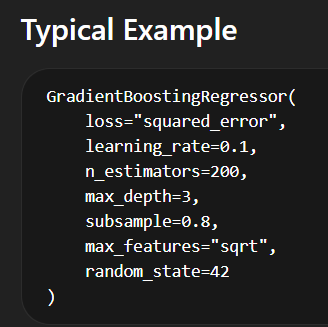

In [ ]:
#Initialize few parameter for Hyperparamter tuning
knn_params = {"n_neighbors": [2, 3, 10, 20, 40, 50]}
rf_params = {"max_depth": [5, 8, 15, None, 10],
             "max_features": [5, 7, 8],
             "min_samples_split": [2, 8, 15, 20],
             "n_estimators": [100, 200, 500, 1000]}
gradient_params={"loss": ['squared_error','huber','absolute_error'],
             "criterion": ['friedman_mse','squared_error','mse'],
             "min_samples_split": [2, 8, 15, 20],
             "n_estimators": [100, 200, 500],
              "max_depth": [5, 8, 15, None, 10],
            }

# In "loss" and "alpha" parameter values documentation -: the "model" term  refers to the "BASE-MODEL / BASE-LEARNER"

example of loss="huber" with "alpha" value-:
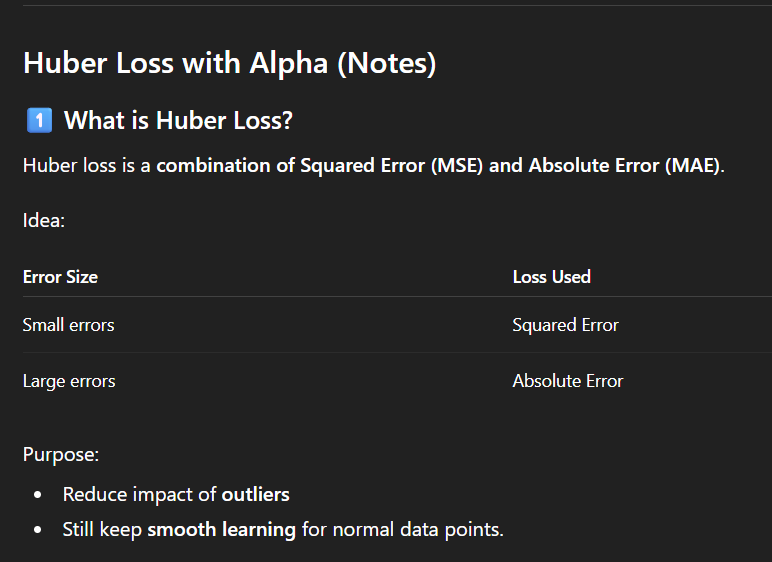
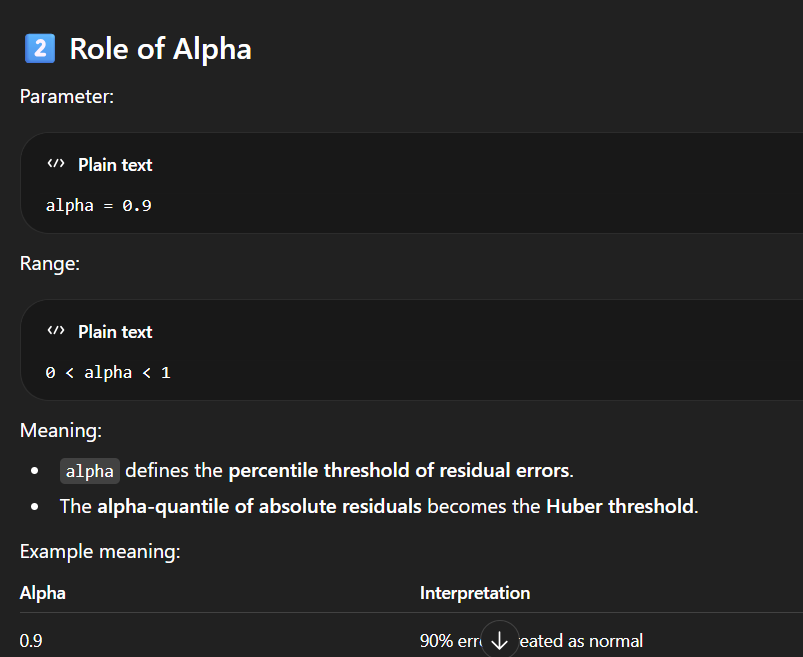
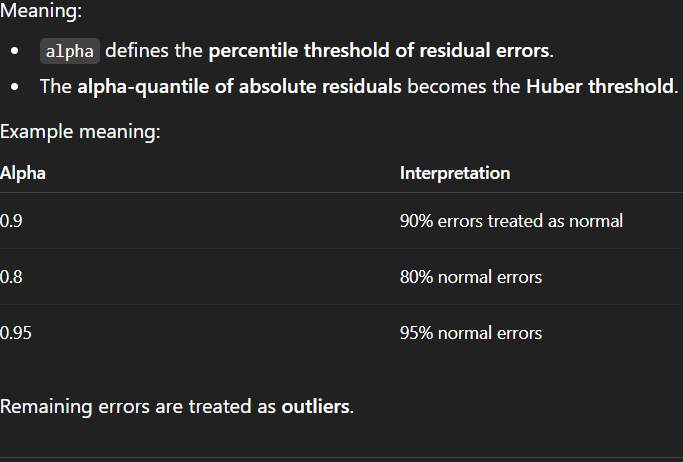
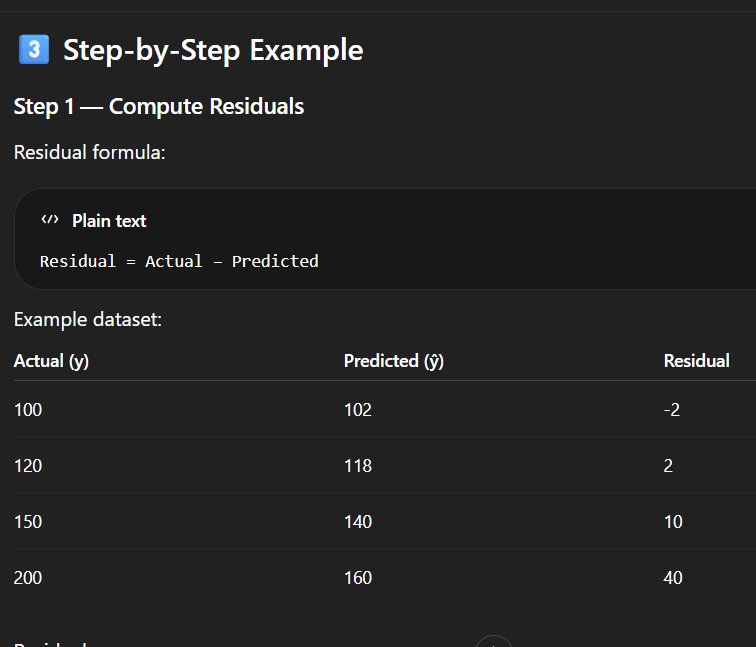
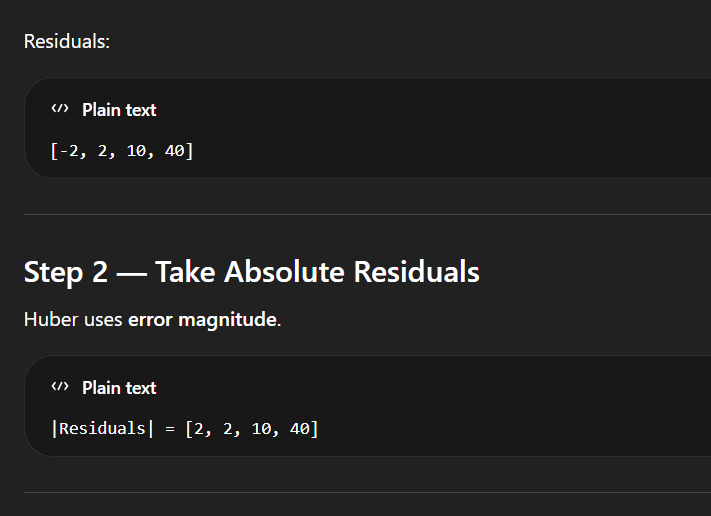
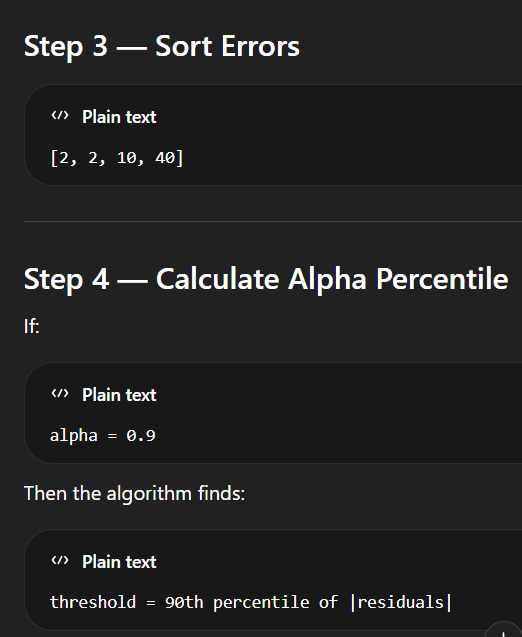
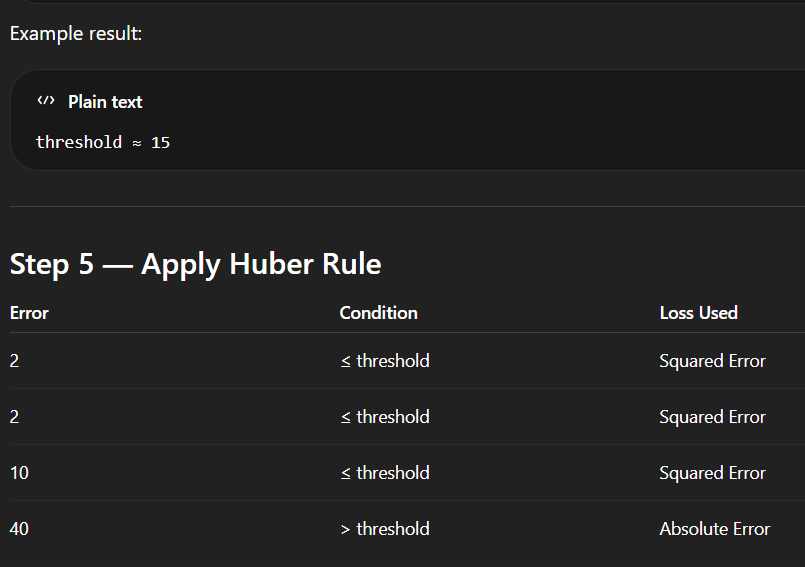
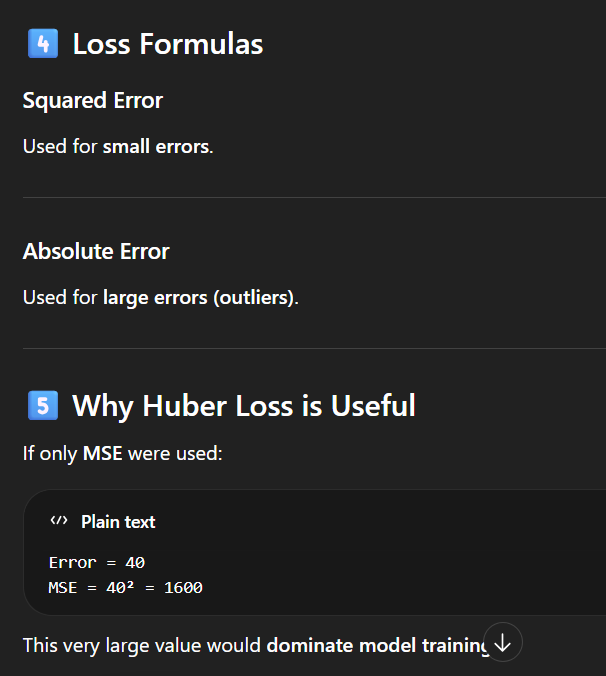
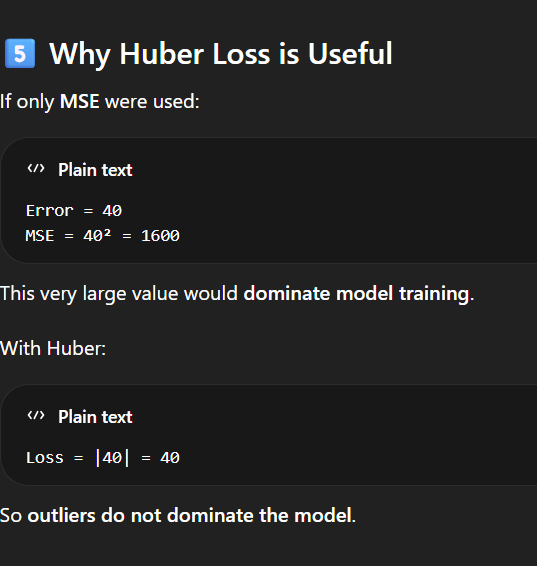
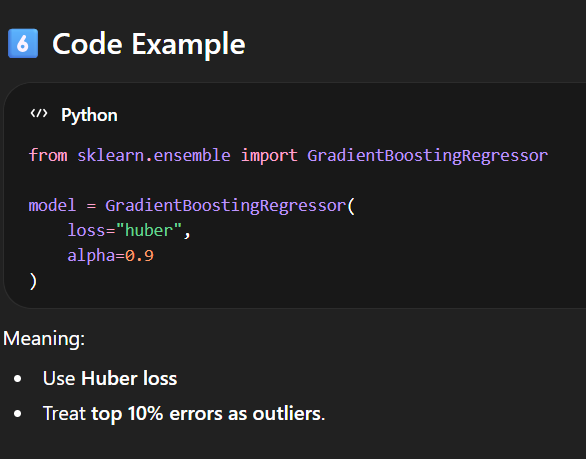
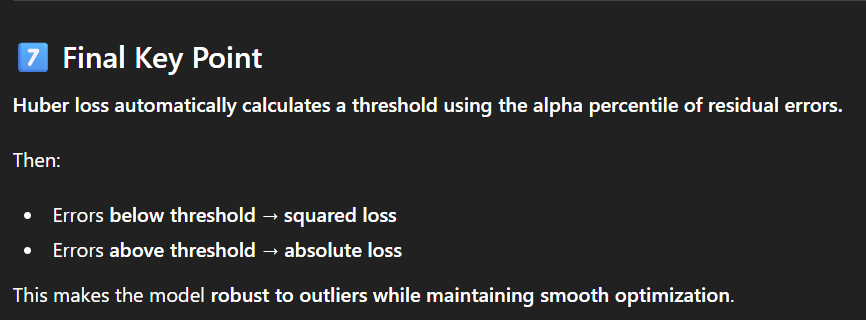


1️⃣ Robust to outliers
A model that is not strongly affected by extreme values, so a few unusual data points do not significantly change the predictions. [Gets less affected by OUTLIERS]

2️⃣ Sensitive to outliers
A model that gets strongly influenced by extreme values, meaning a few unusual data points can greatly change the model’s predictions. [Gets MORE affected by OUTLIERS]

3️⃣ Conservative model
A model that makes fewer splits or simpler decisions to avoid overfitting, focusing on stable and general patterns in data. [Tends to give Generalized Model]

4️⃣ Aggressive model
A model that creates many splits and fits the training data very closely, trying to capture even small patterns but increasing the risk of overfitting. [Tends to give OVERFITTED Model]

In [38]:
# Model list for HYPERPARAMETER-TUNING-:
randomcv_models = [
                                    ('KNN',KNeighborsRegressor(),knn_params),
                                    ("Gradient Boosting Regressor",GradientBoostingRegressor(),gradient_params),
                                    ("RF",RandomForestRegressor(),rf_params),
                                  ]

# HYPERPARAMETER TUNING-:

In [39]:

from sklearn.model_selection import RandomizedSearchCV

model_param = {}
for name,model,params in randomcv_models:
    random = RandomizedSearchCV(estimator=model,
                                param_distributions=params,
                                n_iter=100,
                                cv=3,
                                verbose=2,
                                n_jobs=-1)
    random.fit(X_train,y_train)
    model_param[name] = (random.best_params_,random.best_estimator_)

    for model_name in model_param:
        print(f"---------------- Best Params for {model_name} -------------------")
        print(model_param[model_name])

Fitting 3 folds for each of 6 candidates, totalling 18 fits
---------------- Best Params for KNN -------------------
({'n_neighbors': 10}, KNeighborsRegressor(n_neighbors=10))
Fitting 3 folds for each of 100 candidates, totalling 300 fits
---------------- Best Params for KNN -------------------
({'n_neighbors': 10}, KNeighborsRegressor(n_neighbors=10))
---------------- Best Params for Gradient Boosting Regressor -------------------
({'n_estimators': 20, 'min_samples_split': 20, 'max_depth': None, 'loss': 'squared_error', 'criterion': 'squared_error'}, GradientBoostingRegressor(criterion='squared_error', max_depth=None,
                          min_samples_split=20, n_estimators=20))
Fitting 3 folds for each of 100 candidates, totalling 300 fits
---------------- Best Params for KNN -------------------
({'n_neighbors': 10}, KNeighborsRegressor(n_neighbors=10))
---------------- Best Params for Gradient Boosting Regressor -------------------
({'n_estimators': 20, 'min_samples_split': 20, 

In [40]:
model_param

{'KNN': ({'n_neighbors': 10}, KNeighborsRegressor(n_neighbors=10)),
 'Gradient Boosting Regressor': ({'n_estimators': 20,
   'min_samples_split': 20,
   'max_depth': None,
   'loss': 'squared_error',
   'criterion': 'squared_error'},
  GradientBoostingRegressor(criterion='squared_error', max_depth=None,
                            min_samples_split=20, n_estimators=20)),
 'RF': ({'n_estimators': 100,
   'min_samples_split': 2,
   'max_features': 8,
   'max_depth': None},
  RandomForestRegressor(max_features=8))}

In [41]:
list(model_param.values())

[({'n_neighbors': 10}, KNeighborsRegressor(n_neighbors=10)),
 ({'n_estimators': 20,
   'min_samples_split': 20,
   'max_depth': None,
   'loss': 'squared_error',
   'criterion': 'squared_error'},
  GradientBoostingRegressor(criterion='squared_error', max_depth=None,
                            min_samples_split=20, n_estimators=20)),
 ({'n_estimators': 100,
   'min_samples_split': 2,
   'max_features': 8,
   'max_depth': None},
  RandomForestRegressor(max_features=8))]

In [42]:
len(list(model_param.values()))

3

In [44]:
list(model_param.values())[1][1]

GradientBoostingRegressor(criterion='squared_error', max_depth=None,
                          min_samples_split=20, n_estimators=20)

In [45]:
list(model_param.values())[1][1].loss

'squared_error'

In [47]:
list(model_param.values())[1][1].n_estimators

20

In [48]:
for i in range(len(list(model_param.values()))):
    model = list(model_param.values())[i][1]
    
     # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    model_train_mae , model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)

    model_test_mae , model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)
    
    print(list(model_param.keys())[i])
    
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    
    print('='*35)
    print('\n')

KNN
Model performance for Training set
- Root Mean Squared Error: 363460.7706
- Mean Absolute Error: 103472.0474
- R2 Score: 0.8371
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 263888.0623
- Mean Absolute Error: 117496.2131
- R2 Score: 0.9075


Gradient Boosting Regressor
Model performance for Training set
- Root Mean Squared Error: 149295.8519
- Mean Absolute Error: 75266.6459
- R2 Score: 0.9725
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 259837.2310
- Mean Absolute Error: 119762.6355
- R2 Score: 0.9103


RF
Model performance for Training set
- Root Mean Squared Error: 145052.1498
- Mean Absolute Error: 39868.3871
- R2 Score: 0.9741
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 210764.4575
- Mean Absolute Error: 98905.0111
- R2 Score: 0.9410





Due to HYPER-PARAMETER TUNING-: all the PERFORMANCE-METRICS of Gradient-Boost Regressor has been IMPROVED as compared to the same Gradient-Boost Regressor with default PARAMETERS and infact if we play more with parameters of Gradient-Boosting-Regressor .i.e. do MORE hyper-parameter tuning on gradient boost regressor then it will DEFINETLY perform BETTER than Random Forest Regressor for this given REGRESSION P.S.